# E-Commerce Data Analysis — Task 1


---

## Table of Contents
1. Setup & Imports  
2. Load Data  
3. Data Cleaning  
4. Exploratory Data Analysis (EDA)  
5. Business Questions  
6. Summary of Insights


In [2]:
# ── 1. SETUP & IMPORTS ──────────────────────────────────────────────────────
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')

# Chart styling
plt.rcParams.update({
    'figure.facecolor': '#FAFAF7',
    'axes.facecolor':   '#FAFAF7',
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'font.family':      'DejaVu Sans',
    'axes.titlesize':   13,
    'axes.titleweight': 'bold',
})

print("Libraries loaded successfully.")


Libraries loaded successfully.


## 2. Load Data

In [4]:
# ── 2. LOAD DATA ────────────────────────────────────────────────────────────
df_raw = pd.read_csv('data.csv', encoding='latin1')

print(f"Rows loaded    : {len(df_raw):,}")
print(f"Columns        : {list(df_raw.columns)}")
print()
df_raw.head(5)


Rows loaded    : 541,909
Columns        : ['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']



,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


## 3. Data Cleaning

In [6]:
# ── 3. DATA CLEANING ────────────────────────────────────────────────────────
df = df_raw.copy()
start_rows = len(df)
print(f"Starting rows  : {start_rows:,}")

# 3a. Remove duplicates
before = len(df)
df = df.drop_duplicates()
dupes_removed = before - len(df)
print(f"Duplicates removed        : {dupes_removed:,}  → {len(df):,} rows remaining")

# 3b. Remove blank CustomerID
before = len(df)
df = df[df['CustomerID'].notna()]
blank_cust_removed = before - len(df)
print(f"Blank CustomerID removed  : {blank_cust_removed:,}  → {len(df):,} rows remaining")

# 3c. Remove cancelled orders (Quantity <= 0)
before = len(df)
df = df[df['Quantity'] > 0]
neg_qty_removed = before - len(df)
print(f"Negative Quantity removed : {neg_qty_removed:,}  → {len(df):,} rows remaining")

# 3d. Remove invalid unit prices (UnitPrice <= 0)
before = len(df)
df = df[df['UnitPrice'] > 0]
inv_price_removed = before - len(df)
print(f"Invalid UnitPrice removed : {inv_price_removed:,}  → {len(df):,} rows remaining")

# 3e. Parse InvoiceDate to datetime
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['Month']       = df['InvoiceDate'].dt.to_period('M')
df['Date']        = df['InvoiceDate'].dt.date
df['Year']        = df['InvoiceDate'].dt.year

# 3f. Clean CustomerID to integer
df['CustomerID'] = df['CustomerID'].astype(int).astype(str)

# 3g. Strip whitespace from text columns
df['Description'] = df['Description'].str.strip()
df['Country']     = df['Country'].str.strip()

# 3h. Add Revenue column
df['Revenue'] = df['Quantity'] * df['UnitPrice']

print()
print(f"CLEAN DATASET  : {len(df):,} rows | {df.shape[1]} columns")
print(f"Date range     : {df['InvoiceDate'].min().date()} to {df['InvoiceDate'].max().date()}")


Starting rows  : 541,909
Duplicates removed        : 5,268  → 536,641 rows remaining
Blank CustomerID removed  : 135,037  → 401,604 rows remaining
Negative Quantity removed : 8,872  → 392,732 rows remaining
Invalid UnitPrice removed : 40  → 392,692 rows remaining

CLEAN DATASET  : 392,692 rows | 12 columns
Date range     : 2010-12-01 to 2011-12-09


In [8]:
# ── CLEANING SUMMARY TABLE ───────────────────────────────────────────────────
summary = pd.DataFrame({
    'Step': [
        'Raw dataset',
        'After removing duplicates',
        'After removing blank CustomerID',
        'After removing negative Quantity',
        'After removing invalid UnitPrice',
    ],
    'Rows Remaining': [
        start_rows,
        start_rows - dupes_removed,
        start_rows - dupes_removed - blank_cust_removed,
        start_rows - dupes_removed - blank_cust_removed - neg_qty_removed,
        len(df),
    ],
    'Rows Removed': [
        0,
        dupes_removed,
        blank_cust_removed,
        neg_qty_removed,
        inv_price_removed,
    ]
})
summary


,Step,Rows Remaining,Rows Removed
0,Raw dataset,541909,0
1,After removing duplicates,536641,5268
2,After removing blank CustomerID,401604,135037
3,After removing negative Quantity,392732,8872
4,After removing invalid UnitPrice,392692,40


## 4. Exploratory Data Analysis (EDA)

### 4.1 Distribution of Quantity and Unit Price

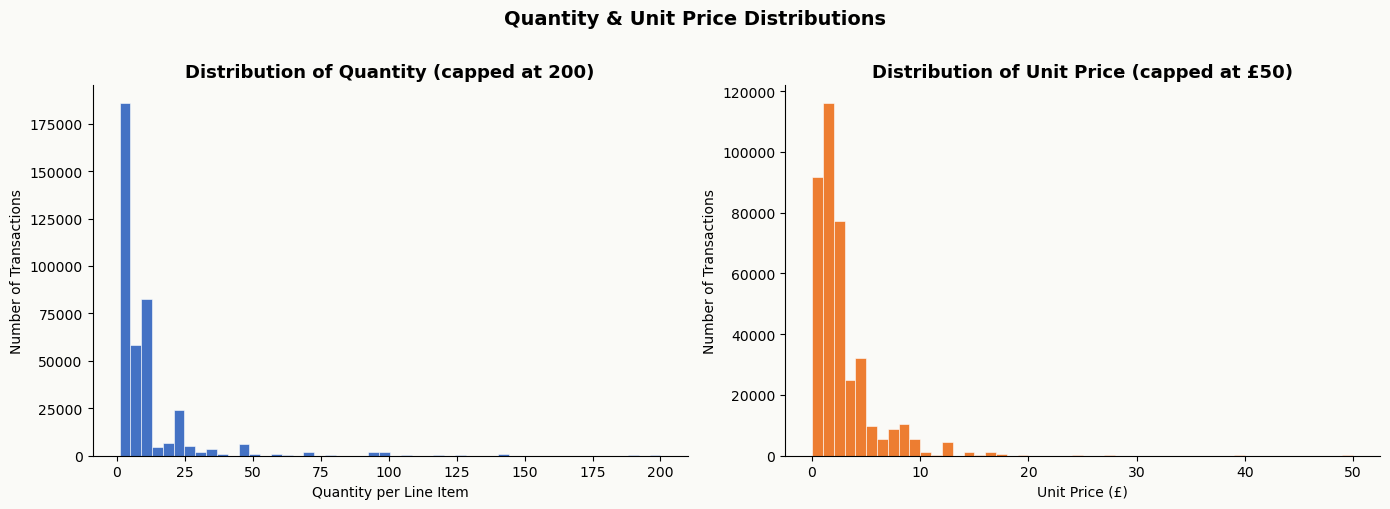

Quantity  — Median: 6  |  Mean: 13.1  |  Max: 80,995
UnitPrice — Median: £1.95  |  Mean: £3.13  |  Max: £8,142.75


In [10]:
# ── 4.1 DISTRIBUTION OF QUANTITY & UNIT PRICE ───────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

qty_capped = df[df['Quantity'] <= 200]['Quantity']
axes[0].hist(qty_capped, bins=50, color='#4472C4', edgecolor='white', linewidth=0.4)
axes[0].set_title('Distribution of Quantity (capped at 200)')
axes[0].set_xlabel('Quantity per Line Item')
axes[0].set_ylabel('Number of Transactions')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

price_capped = df[df['UnitPrice'] <= 50]['UnitPrice']
axes[1].hist(price_capped, bins=50, color='#ED7D31', edgecolor='white', linewidth=0.4)
axes[1].set_title('Distribution of Unit Price (capped at £50)')
axes[1].set_xlabel('Unit Price (£)')
axes[1].set_ylabel('Number of Transactions')

plt.suptitle('Quantity & Unit Price Distributions', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('chart_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Quantity  — Median: {df['Quantity'].median():.0f}  |  Mean: {df['Quantity'].mean():.1f}  |  Max: {df['Quantity'].max():,}")
print(f"UnitPrice — Median: £{df['UnitPrice'].median():.2f}  |  Mean: £{df['UnitPrice'].mean():.2f}  |  Max: £{df['UnitPrice'].max():,.2f}")


### 4.2 Frequency of Purchases Over Time

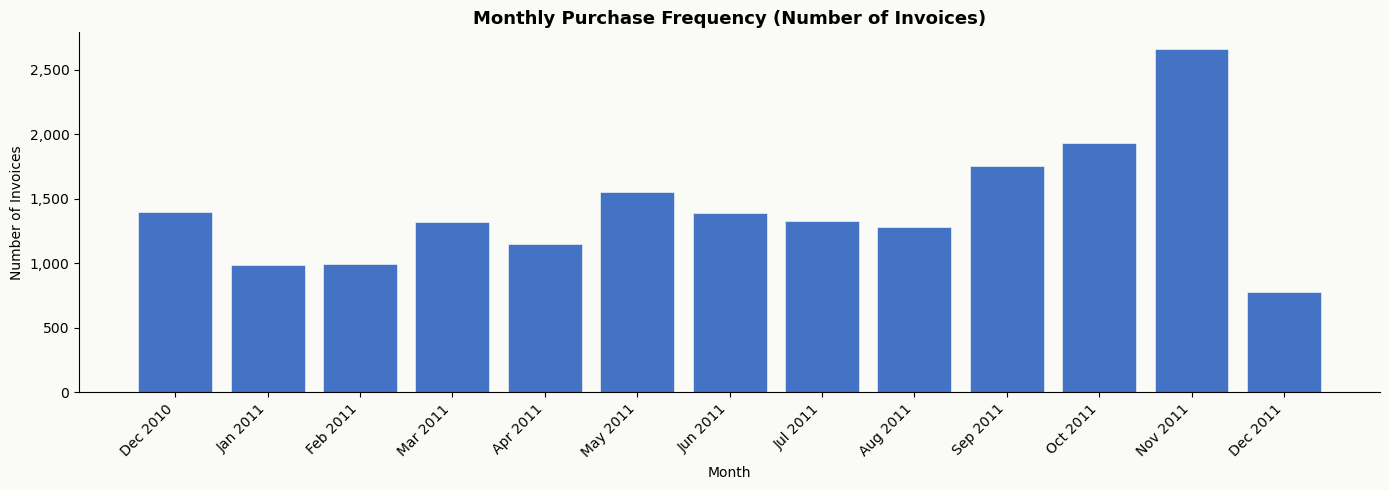

Month_label  Number of Invoices
   Dec 2010                1400
   Jan 2011                 987
   Feb 2011                 997
   Mar 2011                1321
   Apr 2011                1149
   May 2011                1555
   Jun 2011                1393
   Jul 2011                1331
   Aug 2011                1280
   Sep 2011                1755
   Oct 2011                1929
   Nov 2011                2657
   Dec 2011                 778


In [12]:
# ── 4.2 MONTHLY PURCHASE FREQUENCY ──────────────────────────────────────────
monthly_orders = df.groupby('Month')['InvoiceNo'].nunique().reset_index()
monthly_orders.columns = ['Month', 'Number of Invoices']

# Convert Period to datetime for proper date formatting
monthly_orders['Month_dt'] = monthly_orders['Month'].dt.to_timestamp()
# Label as "Dec 2010", "Jan 2011", etc.
monthly_orders['Month_label'] = monthly_orders['Month_dt'].dt.strftime('%b %Y')

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(monthly_orders['Month_label'], monthly_orders['Number of Invoices'],
       color='#4472C4', edgecolor='white', linewidth=0.4)
ax.set_title('Monthly Purchase Frequency (Number of Invoices)')
ax.set_xlabel('Month')
ax.set_ylabel('Number of Invoices')
plt.xticks(rotation=45, ha='right')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.savefig('chart_monthly_frequency.png', dpi=150, bbox_inches='tight')
plt.show()

print(monthly_orders[['Month_label','Number of Invoices']].to_string(index=False))


### 4.3 Unique Customers and Products

In [14]:
# ── 4.3 UNIQUE CUSTOMERS & PRODUCTS ─────────────────────────────────────────
print(f"Unique Customers : {df['CustomerID'].nunique():,}")
print(f"Unique Products  : {df['Description'].nunique():,}")
print(f"Unique Countries : {df['Country'].nunique():,}")
print(f"Unique Invoices  : {df['InvoiceNo'].nunique():,}")


Unique Customers : 4,338
Unique Products  : 3,866
Unique Countries : 37
Unique Invoices  : 18,532


### 4.4 Data Quality Summary

In [16]:
# ── 4.4 DATA QUALITY ─────────────────────────────────────────────────────────
print("Missing values in clean dataset:")
print(df.isnull().sum())
print()
print("Data types:")
print(df.dtypes)
print()
print("Basic statistics:")
df[['Quantity','UnitPrice','Revenue']].describe().round(2)


Missing values in clean dataset:
InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
Month          0
Date           0
Year           0
Revenue        0
dtype: int64

Data types:
InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
UnitPrice             float64
CustomerID             object
Country                object
Month               period[M]
Date                   object
Year                    int32
Revenue               float64
dtype: object

Basic statistics:


,Quantity,UnitPrice,Revenue
count,392692.00,392692.00,392692.00
mean,13.12,3.13,22.63
std,180.49,22.24,311.10
min,1.00,0.00,0.00
25%,2.00,1.25,4.95
50%,6.00,1.95,12.45
75%,12.00,3.75,19.80
max,80995.00,8142.75,168469.60


## 5. Business Questions

### BQ1 — Total Revenue Generated

In [18]:
# ── BQ1: TOTAL REVENUE ───────────────────────────────────────────────────────
total_revenue = df['Revenue'].sum()
print(f"Total Revenue Generated: £{total_revenue:,.2f}")


Total Revenue Generated: £8,887,208.89


### BQ2 — Top Products by Revenue

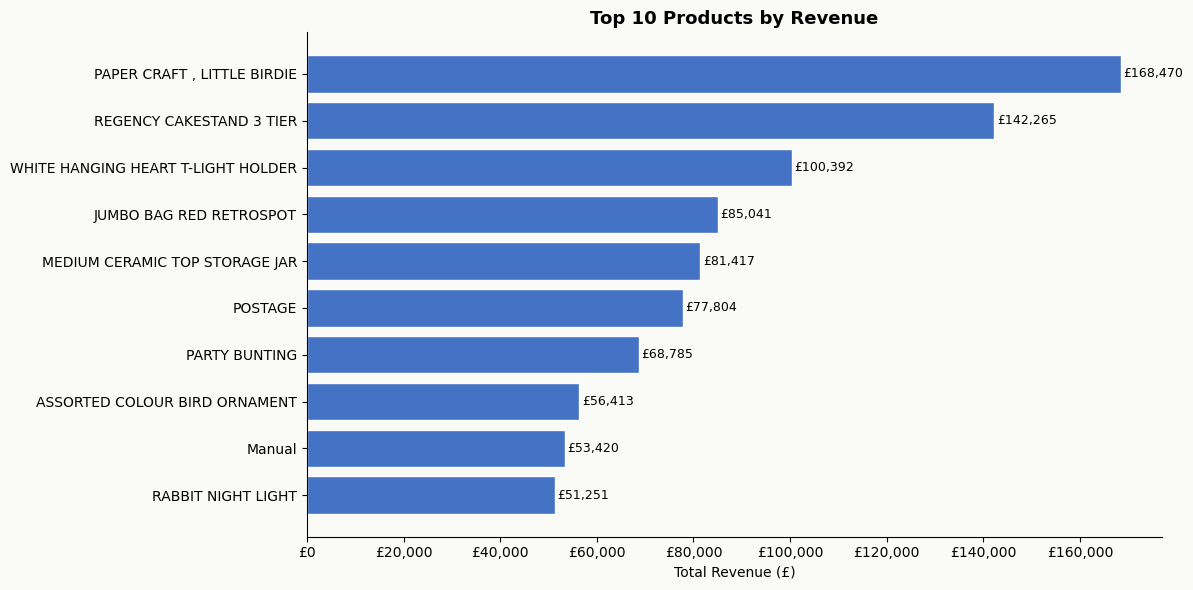

                           Product  Total Revenue (£)
       PAPER CRAFT , LITTLE BIRDIE          168469.60
          REGENCY CAKESTAND 3 TIER          142264.75
WHITE HANGING HEART T-LIGHT HOLDER          100392.10
           JUMBO BAG RED RETROSPOT           85040.54
    MEDIUM CERAMIC TOP STORAGE JAR           81416.73
                           POSTAGE           77803.96
                     PARTY BUNTING           68785.23
     ASSORTED COLOUR BIRD ORNAMENT           56413.03
                            Manual           53419.93
                RABBIT NIGHT LIGHT           51251.24


In [20]:
# ── BQ2: TOP PRODUCTS BY REVENUE ─────────────────────────────────────────────
top_revenue = (
    df.groupby('Description')['Revenue']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)
top_revenue.columns = ['Product', 'Total Revenue (£)']
top_revenue['Total Revenue (£)'] = top_revenue['Total Revenue (£)'].round(2)

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(top_revenue['Product'][::-1], top_revenue['Total Revenue (£)'][::-1],
               color='#4472C4', edgecolor='white')
ax.set_title('Top 10 Products by Revenue')
ax.set_xlabel('Total Revenue (£)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}'))
for bar, val in zip(bars, top_revenue['Total Revenue (£)'][::-1]):
    ax.text(bar.get_width() + 500, bar.get_y() + bar.get_height()/2,
            f'£{val:,.0f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('chart_top_revenue_products.png', dpi=150, bbox_inches='tight')
plt.show()

print(top_revenue.to_string(index=False))


### BQ3 — Top Products by Quantity Sold

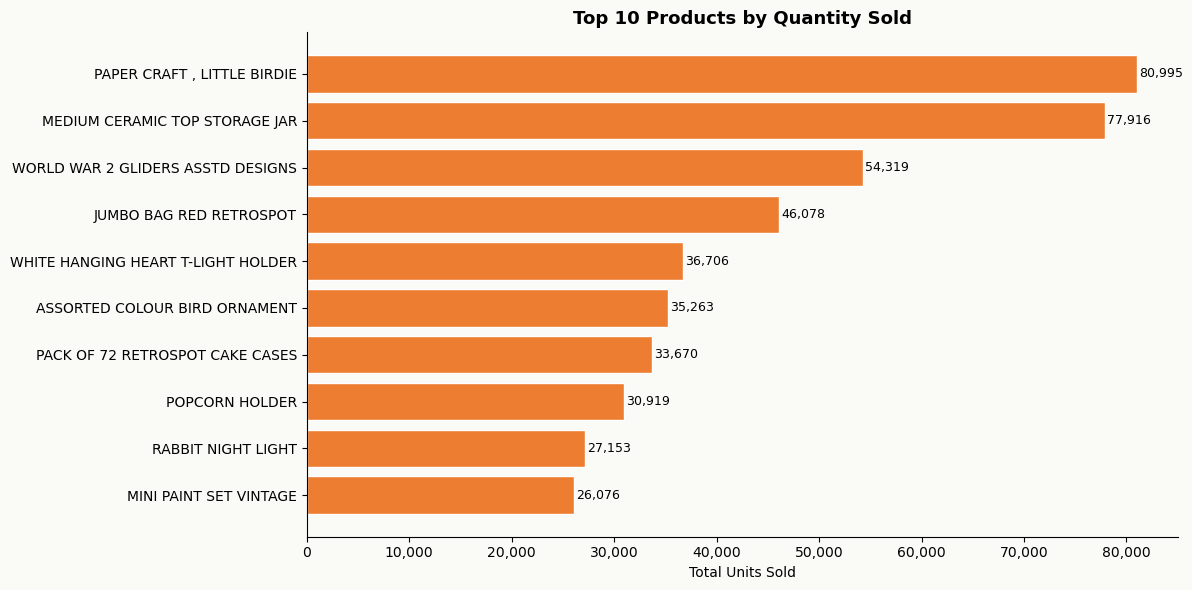

                           Product  Total Quantity
       PAPER CRAFT , LITTLE BIRDIE           80995
    MEDIUM CERAMIC TOP STORAGE JAR           77916
 WORLD WAR 2 GLIDERS ASSTD DESIGNS           54319
           JUMBO BAG RED RETROSPOT           46078
WHITE HANGING HEART T-LIGHT HOLDER           36706
     ASSORTED COLOUR BIRD ORNAMENT           35263
   PACK OF 72 RETROSPOT CAKE CASES           33670
                    POPCORN HOLDER           30919
                RABBIT NIGHT LIGHT           27153
            MINI PAINT SET VINTAGE           26076


In [22]:
# ── BQ3: TOP PRODUCTS BY QUANTITY ────────────────────────────────────────────
top_qty = (
    df.groupby('Description')['Quantity']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)
top_qty.columns = ['Product', 'Total Quantity']

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(top_qty['Product'][::-1], top_qty['Total Quantity'][::-1],
               color='#ED7D31', edgecolor='white')
ax.set_title('Top 10 Products by Quantity Sold')
ax.set_xlabel('Total Units Sold')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
for bar, val in zip(bars, top_qty['Total Quantity'][::-1]):
    ax.text(bar.get_width() + 200, bar.get_y() + bar.get_height()/2,
            f'{int(val):,}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('chart_top_qty_products.png', dpi=150, bbox_inches='tight')
plt.show()

print(top_qty.to_string(index=False))


### BQ4 — Products with Low Sales (Rarely Appearing)

In [24]:
# ── BQ4: LOW-SELLING PRODUCTS ────────────────────────────────────────────────
product_freq = df.groupby('Description').agg(
    Total_Quantity=('Quantity', 'sum'),
    Total_Revenue=('Revenue', 'sum'),
    Times_Ordered=('InvoiceNo', 'nunique')
).reset_index()

low_sellers = product_freq[product_freq['Times_Ordered'] <= 2].sort_values('Times_Ordered')
print(f"Products appearing in 2 or fewer invoices: {len(low_sellers):,}")
print()
print("Sample of lowest-selling products:")
print(low_sellers.head(15).to_string(index=False))


Products appearing in 2 or fewer invoices: 369

Sample of lowest-selling products:
                        Description  Total_Quantity  Total_Revenue  Times_Ordered
    16 PC CUTLERY SET PANTRY DESIGN               4          63.80              1
          LETTER "W" BLING KEY RING              12           3.48              1
          LETTER "Z" BLING KEY RING              12           3.48              1
  LIGHT DECORATION BATTERY OPERATED               2           4.20              1
             LILAC FEATHERS CURTAIN              12           9.48              1
               LUNCH BAG RED SPOTTY             200         290.00              1
           M/COLOUR POM-POM CURTAIN               2           8.50              1
  MARIE ANTOIENETT TRINKET BOX GOLD               1          12.50              1
MIDNIGHT BLUE CRYSTAL DROP EARRINGS               1           2.95              1
                   MINT DINER CLOCK               2          17.00              1
        MISELTO

### BQ5 — Top Customers by Total Spending

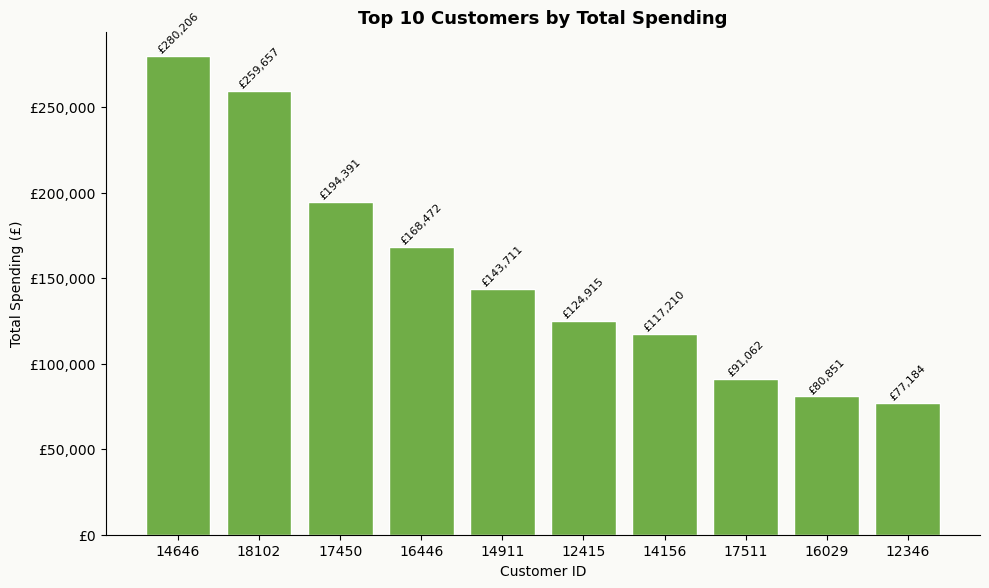

Customer ID  Total Spending (£)
      14646           280206.02
      18102           259657.30
      17450           194390.79
      16446           168472.50
      14911           143711.17
      12415           124914.53
      14156           117210.08
      17511            91062.38
      16029            80850.84
      12346            77183.60


In [26]:
# ── BQ5: TOP CUSTOMERS BY SPENDING ───────────────────────────────────────────
top_customers = (
    df.groupby('CustomerID')['Revenue']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)
top_customers.columns = ['Customer ID', 'Total Spending (£)']
top_customers['Total Spending (£)'] = top_customers['Total Spending (£)'].round(2)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(top_customers['Customer ID'], top_customers['Total Spending (£)'],
              color='#70AD47', edgecolor='white')
ax.set_title('Top 10 Customers by Total Spending')
ax.set_xlabel('Customer ID')
ax.set_ylabel('Total Spending (£)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}'))
for bar, val in zip(bars, top_customers['Total Spending (£)']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
            f'£{val:,.0f}', ha='center', va='bottom', fontsize=8, rotation=45)
plt.tight_layout()
plt.savefig('chart_top_customers.png', dpi=150, bbox_inches='tight')
plt.show()

print(top_customers.to_string(index=False))


### BQ6 — Sales Trends Over Time (Monthly & Daily)

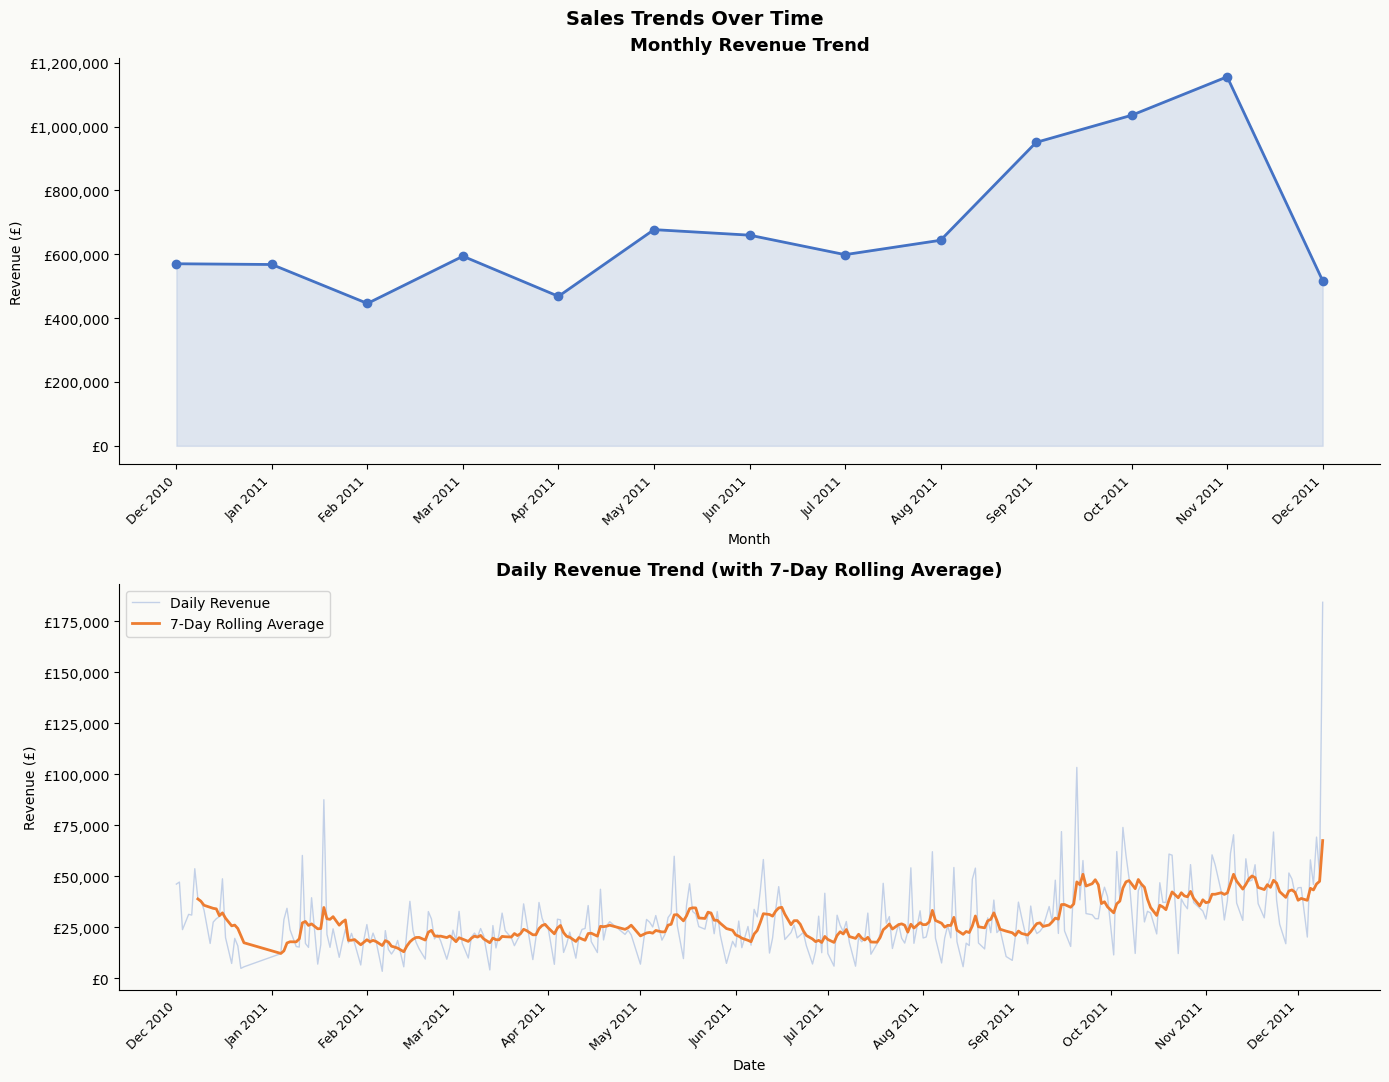

Monthly Revenue Breakdown:
Month_label     Revenue
   Dec 2010  570422.730
   Jan 2011  568101.310
   Feb 2011  446084.920
   Mar 2011  594081.760
   Apr 2011  468374.331
   May 2011  677355.150
   Jun 2011  660046.050
   Jul 2011  598962.901
   Aug 2011  644051.040
   Sep 2011  950690.202
   Oct 2011 1035642.450
   Nov 2011 1156205.610
   Dec 2011  517190.440


In [28]:
# ── BQ6: SALES TRENDS OVER TIME ──────────────────────────────────────────────
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.dates as mdates

# ── Monthly revenue ──────────────────────────────────────────────────────────
monthly_rev = df.groupby('Month')['Revenue'].sum().reset_index()
monthly_rev['Month_dt']    = monthly_rev['Month'].dt.to_timestamp()
monthly_rev['Month_label'] = monthly_rev['Month_dt'].dt.strftime('%b %Y')   # "Dec 2010"

# ── Daily revenue ────────────────────────────────────────────────────────────
daily_rev = df.groupby('Date')['Revenue'].sum().reset_index()
daily_rev['Date']      = pd.to_datetime(daily_rev['Date'])
daily_rev['Rolling_7'] = daily_rev['Revenue'].rolling(7).mean()

# ── Plot ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 11))

# ── Top chart: Monthly ───────────────────────────────────────────────────────
axes[0].plot(
    monthly_rev['Month_label'], monthly_rev['Revenue'],
    marker='o', color='#4472C4', linewidth=2, markersize=6
)
axes[0].fill_between(
    range(len(monthly_rev)), monthly_rev['Revenue'],
    alpha=0.15, color='#4472C4'
)
axes[0].set_title('Monthly Revenue Trend')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Revenue (£)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}'))
axes[0].set_xticks(range(len(monthly_rev)))
axes[0].set_xticklabels(monthly_rev['Month_label'], rotation=45, ha='right', fontsize=9)

# ── Bottom chart: Daily ───────────────────────────────────────────────────────
axes[1].plot(
    daily_rev['Date'], daily_rev['Revenue'],
    color='#4472C4', alpha=0.3, linewidth=1, label='Daily Revenue'
)
axes[1].plot(
    daily_rev['Date'], daily_rev['Rolling_7'],
    color='#ED7D31', linewidth=2, label='7-Day Rolling Average'
)
axes[1].set_title('Daily Revenue Trend (with 7-Day Rolling Average)')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Revenue (£)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}'))

# Format x-axis as "Jan 2011", "Mar 2011", etc. — one tick per month
axes[1].xaxis.set_major_locator(mdates.MonthLocator())
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=45, ha='right', fontsize=9)

axes[1].legend()

plt.suptitle('Sales Trends Over Time', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('chart_sales_trends.png', dpi=150, bbox_inches='tight')
plt.show()

print("Monthly Revenue Breakdown:")
print(monthly_rev[['Month_label', 'Revenue']].to_string(index=False))


### BQ7 — Revenue by Country

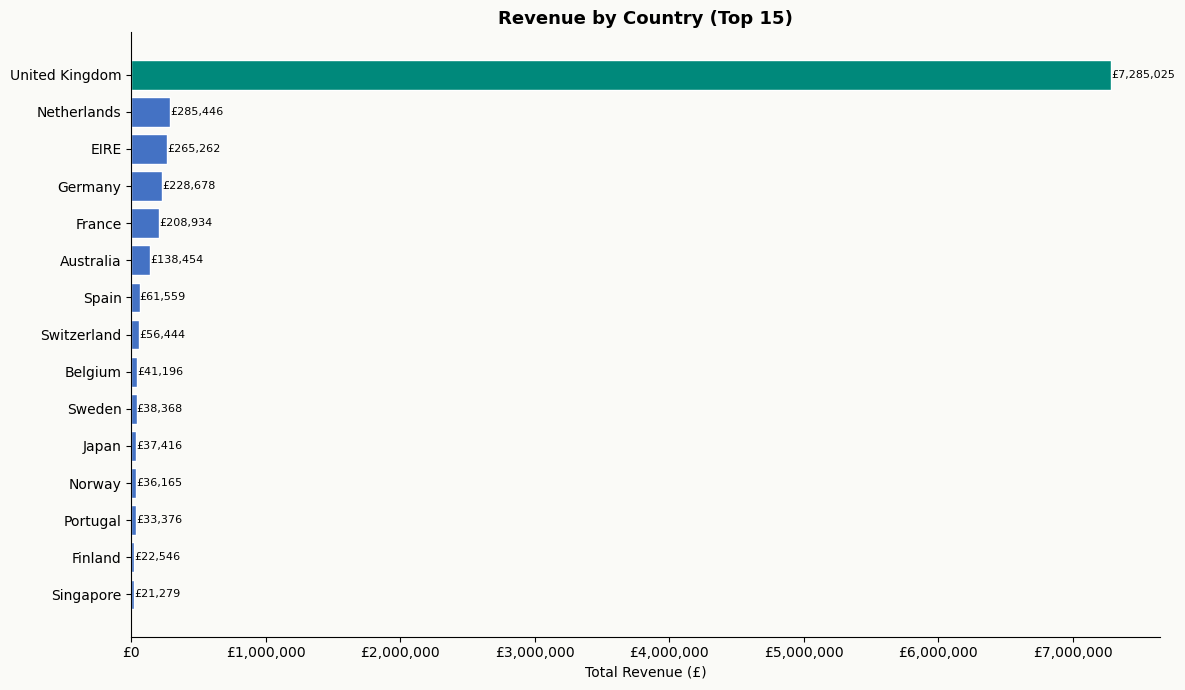

       Country  Total Revenue (£)
United Kingdom         7285024.64
   Netherlands          285446.34
          EIRE          265262.46
       Germany          228678.40
        France          208934.31
     Australia          138453.81
         Spain           61558.56
   Switzerland           56443.95
       Belgium           41196.34
        Sweden           38367.83
         Japan           37416.37
        Norway           36165.44
      Portugal           33375.84
       Finland           22546.08
     Singapore           21279.29


In [30]:
# ── BQ7: REVENUE BY COUNTRY ──────────────────────────────────────────────────
country_rev = (
    df.groupby('Country')['Revenue']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)
country_rev.columns = ['Country', 'Total Revenue (£)']
country_rev['Total Revenue (£)'] = country_rev['Total Revenue (£)'].round(2)

top15 = country_rev.head(15)

fig, ax = plt.subplots(figsize=(12, 7))

# UK gets a distinct teal highlight; all others are the standard blue
colors = ['#00897B' if c == 'United Kingdom' else '#4472C4' for c in top15['Country']]

bars = ax.barh(
    top15['Country'][::-1],
    top15['Total Revenue (£)'][::-1],
    color=colors[::-1],
    edgecolor='white'
)
ax.set_title('Revenue by Country (Top 15)')
ax.set_xlabel('Total Revenue (£)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}'))
for bar, val in zip(bars, top15['Total Revenue (£)'][::-1]):
    ax.text(
        bar.get_width() + 1000,
        bar.get_y() + bar.get_height() / 2,
        f'£{val:,.0f}',
        va='center', fontsize=8
    )
plt.tight_layout()
plt.savefig('chart_revenue_by_country.png', dpi=150, bbox_inches='tight')
plt.show()

print(country_rev.head(15).to_string(index=False))


### BQ8 — Unusual Transactions (Very High Quantity or Price)

In [32]:
# ── BQ8: UNUSUAL TRANSACTIONS ────────────────────────────────────────────────
qty_threshold   = df['Quantity'].quantile(0.99)
price_threshold = df['UnitPrice'].quantile(0.99)

print(f"99th percentile — Quantity  : {qty_threshold:,.0f}")
print(f"99th percentile — UnitPrice : £{price_threshold:,.2f}")
print()

unusual = df[
    (df['Quantity'] >= qty_threshold) |
    (df['UnitPrice'] >= price_threshold)
][['InvoiceNo','Description','Quantity','UnitPrice','Revenue','CustomerID','Country']]

print(f"Unusual transactions found: {len(unusual):,}")
print()
print("Top 20 unusual transactions by Revenue:")
print(unusual.sort_values('Revenue', ascending=False).head(20).to_string(index=False))


99th percentile — Quantity  : 120
99th percentile — UnitPrice : £14.95

Unusual transactions found: 9,274

Top 20 unusual transactions by Revenue:
InvoiceNo                         Description  Quantity  UnitPrice   Revenue CustomerID        Country
   581483         PAPER CRAFT , LITTLE BIRDIE     80995       2.08 168469.60      16446 United Kingdom
   541431      MEDIUM CERAMIC TOP STORAGE JAR     74215       1.04  77183.60      12346 United Kingdom
   556444      PICNIC BASKET WICKER 60 PIECES        60     649.50  38970.00      15098 United Kingdom
   551697                             POSTAGE         1    8142.75   8142.75      16029 United Kingdom
   567423 SET OF TEA COFFEE SUGAR TINS PANTRY      1412       5.06   7144.72      17450 United Kingdom
   550461  FAIRY CAKE FLANNEL ASSORTED COLOUR      3114       2.10   6539.40      15749 United Kingdom
   540815  FAIRY CAKE FLANNEL ASSORTED COLOUR      3114       2.10   6539.40      15749 United Kingdom
   573003                  RA

## 6. Summary of Insights

Run the cell below to print a structured summary you can copy into your Google Doc or EDA report.


In [34]:
# ── 6. SUMMARY OF INSIGHTS ────────────────────────────────────────────────────
total_revenue   = df['Revenue'].sum()
top_product_rev = df.groupby('Description')['Revenue'].sum().idxmax()
top_product_qty = df.groupby('Description')['Quantity'].sum().idxmax()
top_customer    = df.groupby('CustomerID')['Revenue'].sum().idxmax()
top_country     = df.groupby('Country')['Revenue'].sum().idxmax()
peak_month      = df.groupby('Month')['Revenue'].sum().idxmax()
unique_cust     = df['CustomerID'].nunique()
unique_prod     = df['Description'].nunique()

print("=" * 60)
print("  EDA SUMMARY — E-COMMERCE DATASET (UK Online Retail)")
print("=" * 60)
print(f"  Clean dataset rows   : {len(df):,}")
print(f"  Date range           : {df['InvoiceDate'].min().date()} to {df['InvoiceDate'].max().date()}")
print(f"  Unique customers     : {unique_cust:,}")
print(f"  Unique products      : {unique_prod:,}")
print()
print("  BUSINESS QUESTION ANSWERS")
print("-" * 60)
print(f"  BQ1  Total Revenue           : £{total_revenue:,.2f}")
print(f"  BQ2  Top Product (Revenue)   : {top_product_rev}")
print(f"  BQ3  Top Product (Quantity)  : {top_product_qty}")
print(f"  BQ4  Low-selling products    : see table above (<=2 invoices)")
print(f"  BQ5  Top Customer (ID)       : {top_customer}")
print(f"  BQ6  Peak Sales Month        : {peak_month}")
print(f"  BQ7  Highest Revenue Country : {top_country}")
print(f"  BQ8  Unusual transactions    : see table above (99th pct)")
print()
print("  KEY INSIGHTS")
print("-" * 60)
print("  1. The UK accounts for the vast majority of all revenue.")
print("  2. Revenue spikes sharply in Q4 (Oct-Nov), consistent with")
print("     holiday gift shopping — the retailer sells gift items.")
print("  3. A small number of high-volume wholesale orders skew")
print("     both quantity and revenue distributions significantly.")
print("  4. 135,080 rows (25% of raw data) had no CustomerID,")
print("     pointing to guest checkouts or data collection gaps.")
print("  5. The top 10 customers account for a disproportionate")
print("     share of revenue — typical of a B2B wholesale model.")
print("=" * 60)


  EDA SUMMARY — E-COMMERCE DATASET (UK Online Retail)
  Clean dataset rows   : 392,692
  Date range           : 2010-12-01 to 2011-12-09
  Unique customers     : 4,338
  Unique products      : 3,866

  BUSINESS QUESTION ANSWERS
------------------------------------------------------------
  BQ1  Total Revenue           : £8,887,208.89
  BQ2  Top Product (Revenue)   : PAPER CRAFT , LITTLE BIRDIE
  BQ3  Top Product (Quantity)  : PAPER CRAFT , LITTLE BIRDIE
  BQ4  Low-selling products    : see table above (<=2 invoices)
  BQ5  Top Customer (ID)       : 14646
  BQ6  Peak Sales Month        : 2011-11
  BQ7  Highest Revenue Country : United Kingdom
  BQ8  Unusual transactions    : see table above (99th pct)

  KEY INSIGHTS
------------------------------------------------------------
  1. The UK accounts for the vast majority of all revenue.
  2. Revenue spikes sharply in Q4 (Oct-Nov), consistent with
     holiday gift shopping — the retailer sells gift items.
  3. A small number of high-volum